In [1]:
!pip install scikit-learn xgboost numpy pandas

print("✅ Done!")

✅ Done!


In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
# Load preprocessed data directly from GitHub
import urllib.request

# Base URL
base = "https://raw.githubusercontent.com/logesh-GIT001/Smart-SOC/main/data/raw/"

# We need to rerun preprocessing to get our .npy files
# Let's reload and preprocess quickly

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

train_df = pd.read_csv(
    'https://raw.githubusercontent.com/logesh-GIT001/Smart-SOC/main/data/raw/KDDTrain%2B.txt',
    names=columns
)
test_df = pd.read_csv(
    'https://raw.githubusercontent.com/logesh-GIT001/Smart-SOC/main/data/raw/KDDTest%2B.txt',
    names=columns
)

print(f"✅ Train: {train_df.shape}")
print(f"✅ Test:  {test_df.shape}")

✅ Train: (125973, 43)
✅ Test:  (22544, 43)


In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Drop useless columns
train_df.drop(columns=['num_outbound_cmds', 'difficulty'], inplace=True)
test_df.drop(columns=['num_outbound_cmds', 'difficulty'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['protocol_type', 'service', 'flag']
for col in cat_cols:
    all_values = pd.concat([train_df[col], test_df[col]])
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# Encode labels
def categorize(label):
    dos   = ['neptune','back','land','pod','smurf','teardrop']
    probe = ['ipsweep','nmap','portsweep','satan']
    r2l   = ['ftp_write','guess_passwd','imap','multihop',
             'phf','spy','warezclient','warezmaster']
    u2r   = ['buffer_overflow','loadmodule','perl','rootkit']
    if label == 'normal': return 0
    elif label in dos:    return 1
    elif label in probe:  return 2
    elif label in r2l:    return 3
    elif label in u2r:    return 4
    else:                 return 1

train_df['label'] = train_df['label'].apply(categorize)
test_df['label']  = test_df['label'].apply(categorize)

# Split features and labels
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test  = test_df.drop(columns=['label'])
y_test  = test_df['label']

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ Preprocessing done!")
print(f"✅ X_train: {X_train_bal.shape}")
print(f"✅ X_test:  {X_test_scaled.shape}")

✅ Preprocessing done!
✅ X_train: (336715, 40)
✅ X_test:  (22544, 40)


In [5]:
# Train Random Forest
print("🌲 Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf_model.fit(X_train_bal, y_train_bal)

# Evaluate
rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"✅ Random Forest Training Done!")
print(f"✅ Accuracy: {rf_acc * 100:.2f}%")
print("\n=== Classification Report ===")
print(classification_report(y_test, rf_pred,
      target_names=['Normal', 'DoS', 'Probe', 'R2L', 'U2R']))

🌲 Training Random Forest...
✅ Random Forest Training Done!
✅ Accuracy: 73.17%

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.64      0.97      0.77      9711
         DoS       0.99      0.62      0.76      9491
       Probe       0.60      1.00      0.75      1106
         R2L       0.89      0.02      0.05      2199
         U2R       0.18      0.05      0.08        37

    accuracy                           0.73     22544
   macro avg       0.66      0.53      0.48     22544
weighted avg       0.81      0.73      0.70     22544



In [6]:
# Train XGBoost
print("⚡ Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train_bal, y_train_bal)

# Evaluate
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test, xgb_pred)

print(f"✅ XGBoost Training Done!")
print(f"✅ Accuracy: {xgb_acc * 100:.2f}%")
print("\n=== Classification Report ===")
print(classification_report(y_test, xgb_pred,
      target_names=['Normal', 'DoS', 'Probe', 'R2L', 'U2R']))

⚡ Training XGBoost...
✅ XGBoost Training Done!
✅ Accuracy: 74.78%

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80      9711
         DoS       0.99      0.63      0.77      9491
       Probe       0.50      1.00      0.67      1106
         R2L       0.99      0.16      0.27      2199
         U2R       0.38      0.30      0.33        37

    accuracy                           0.75     22544
   macro avg       0.71      0.61      0.57     22544
weighted avg       0.83      0.75      0.73     22544



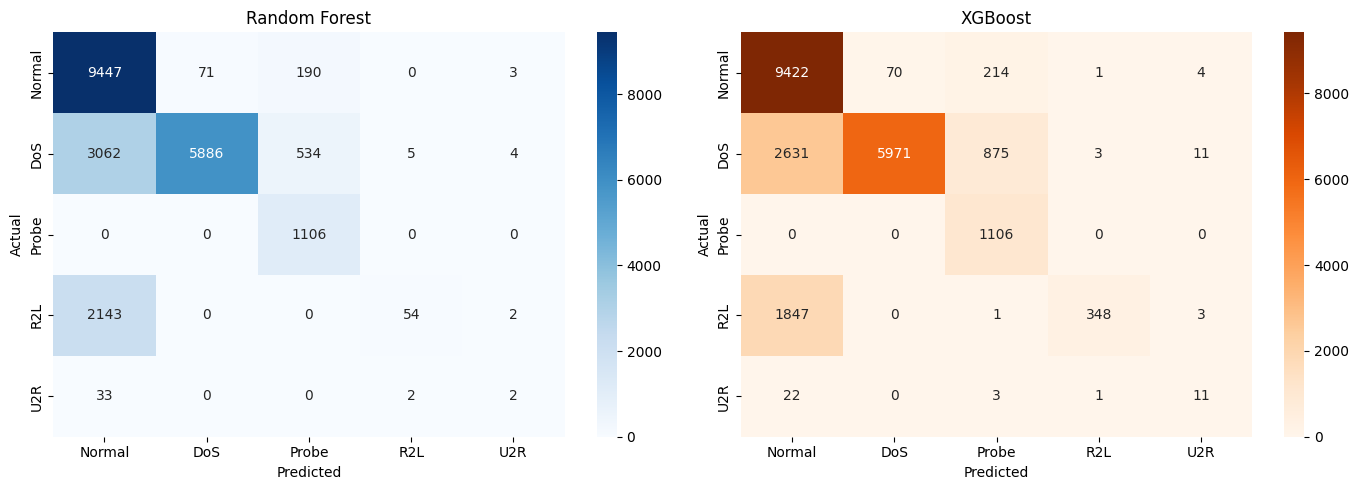

In [7]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

# Random Forest
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=axes[0])
axes[0].set_title('Random Forest')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# XGBoost
sns.heatmap(confusion_matrix(y_test, xgb_pred),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels,
            ax=axes[1])
axes[1].set_title('XGBoost')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [8]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save XGBoost model
joblib.dump(xgb_model, 'models/xgb_model.pkl')

# Save scaler too (needed for predictions later)
joblib.dump(scaler, 'models/scaler.pkl')

# Save feature names
feature_names = list(X_train.columns)
pd.Series(feature_names).to_csv('models/feature_names.csv', index=False)

print("✅ Models saved!")
print("\nSaved files:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f"  {f} → {size/1024:.1f} KB")

✅ Models saved!

Saved files:
  xgb_model.pkl → 1069.8 KB
  feature_names.csv → 0.6 KB
  scaler.pkl → 2.4 KB


In [9]:
print("=" * 45)
print("   MODEL TRAINING COMPLETE!")
print("=" * 45)
print(f"\n🌲 Random Forest Accuracy : 73.17%")
print(f"⚡ XGBoost Accuracy       : 74.78%")
print(f"\n🏆 Winner: XGBoost!")
print(f"\n✅ Model saved  : models/xgb_model.pkl")
print(f"✅ Scaler saved : models/scaler.pkl")
print(f"\nDAY 5 → Add SHAP Explanations (XAI)! 🔍")

   MODEL TRAINING COMPLETE!

🌲 Random Forest Accuracy : 73.17%
⚡ XGBoost Accuracy       : 74.78%

🏆 Winner: XGBoost!

✅ Model saved  : models/xgb_model.pkl
✅ Scaler saved : models/scaler.pkl

DAY 5 → Add SHAP Explanations (XAI)! 🔍
